# **Analisis Data Stroke Menggunakan Stroke Prediction Dataset**

# **Import Library**

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

In [81]:
import pandas as pd

path = "/content/drive/MyDrive/Dataset AVD/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(path)

print("Dataset berhasil dimuat.")

Dataset berhasil dimuat.


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# **Load Dataset**

In [83]:
path = "/content/drive/MyDrive/Dataset AVD/healthcare-dataset-stroke-data.csv"

df = pd.read_csv(path)

df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


# **Business Understanding**

## **Business Objective**

Analisis pada dataset Stroke Prediction ini bertujuan untuk membantu memahami faktor-faktor kesehatan yang berhubungan dengan risiko stroke pada pasien. Fokus utama analisis adalah melihat pengaruh umur, hipertensi, penyakit jantung, kadar glukosa, dan BMI terhadap kemungkinan terjadinya stroke.

Dengan adanya analisis ini diharapkan dapat diperoleh gambaran karakteristik pasien yang memiliki risiko stroke lebih tinggi sehingga dapat menjadi dasar untuk langkah pencegahan maupun pengembangan model prediksi pada tahap selanjutnya.

## **Assess Situation**

Stroke merupakan salah satu penyakit yang memiliki tingkat risiko tinggi dan dipengaruhi oleh berbagai kondisi kesehatan. Dataset yang digunakan berisi data pasien yang mengalami stroke dan yang tidak, sehingga memungkinkan dilakukan perbandingan untuk melihat pola yang muncul dari masing-masing kelompok.

Secara umum data sudah cukup lengkap, namun terdapat beberapa nilai kosong pada kolom BMI serta jumlah data pasien stroke yang lebih sedikit dibandingkan yang tidak stroke. Kondisi ini perlu diperhatikan dalam proses analisis karena dapat mempengaruhi hasil yang diperoleh. Oleh karena itu, diperlukan proses eksplorasi data yang sistematis agar dapat menemukan faktor yang paling berpengaruh terhadap stroke berdasarkan data yang tersedia.

## **Analytic Goals**

Analisis ini bertujuan untuk:

* Melihat gambaran umum dataset

* Mengecek missing value

* Membandingkan pasien stroke dan tidak stroke berdasarkan umur, BMI, dan kadar glukosa

* Menentukan faktor yang paling berpengaruh terhadap stroke

## **Project Plan**

Langkah-langkah yang akan dilakukan dalam analisis:

* Data Understanding
Melihat jumlah data, tipe data, dan mengecek missing value.

* Data Cleaning
Menangani missing value pada kolom BMI.

* Exploratory Data Analysis (EDA)
Membandingkan data stroke dan tidak stroke menggunakan visualisasi sederhana.

* Insight
Menentukan faktor yang paling terlihat berpengaruh terhadap stroke.

* Persiapan Modeling
Mengubah data kategori menjadi numerik jika diperlukan untuk tahap selanjutnya.

# **Data Understanding**

## **Membuat Dataset**

Dataset yang digunakan berasal dari Stroke Prediction Dataset yang berisi data kondisi kesehatan pasien. Dataset ini digunakan untuk menganalisis faktor-faktor yang berhubungan dengan risiko stroke berdasarkan data medis seperti umur, hipertensi, penyakit jantung, kadar glukosa, dan BMI.

In [84]:
path = "/content/drive/MyDrive/Dataset AVD/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(path)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


## **Deskripsi Data**

### **Informasi Data**

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 5110 Baris dan 12 Kolom

### **Informasi Lanjutan**

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB




1.   id: Jumlah baris 5110, tipe data int64
Deskripsi: ID unik untuk setiap pasien.
2.   gender: Jumlah baris 5110, tipe data object
Deskripsi: Jenis kelamin pasien.
3.   age: Jumlah baris 5110, tipe data float64
Deskripsi: Umur pasien.
4.   hypertension: Jumlah baris 5110, tipe data int64
Deskripsi: Status hipertensi pasien (0 = tidak, 1 = ya).
5.   heart_disease: Jumlah baris 5110, tipe data int64
Deskripsi: Status penyakit jantung pasien (0 = tidak, 1 = ya).
6.   ever_married: Jumlah baris 5110, tipe data object
Deskripsi: Status pernah menikah atau tidak.
7.   work_type: Jumlah baris 5110, tipe data object
Deskripsi: Jenis pekerjaan pasien.
8.   Residence_type: Jumlah baris 5110, tipe data object
Deskripsi: Tipe tempat tinggal pasien (Urban atau Rural).
9.   avg_glucose_level: Jumlah baris 5110, tipe data float64
Deskripsi: Rata-rata kadar glukosa dalam darah.
10.  bmi: Jumlah baris 4909, tipe data float64
Deskripsi: Indeks massa tubuh pasien, terdapat missing value.
11.  smoking_status: Jumlah baris 5110, tipe data object
Deskripsi: Status merokok pasien.
12.  stroke: Jumlah baris 5110, tipe data int64
Deskripsi: Status stroke (0 = tidak stroke, 1 = stroke).



### **Informasi Statistik Deskriptif**

In [87]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000




1. Count (Kelengkapan Data) Berdasarkan data, total baris transaksi adalah 155. Maka dapat disimpulkan:


*   Profit hilang 38 data (155 - 117)
*   Product ID hilang 124 data (155 - 31)

Kesimpulan: Kolom Profit dan Product ID mengandung missing values, sementara kolom lainnya udah lengkap (155 data)


---

2. Mean vs Median (Distribusi Data)

* Kolom age

  * Mean ≈ 43

  * Median ≈ 45
  
  Nilai mean dan median yang tidak terlalu jauh menunjukkan distribusi umur cukup merata.

* Kolom avg_glucose_level

  * Mean ≈ 106

  * Median ≈ 91
  
  Nilai rata-rata lebih besar dari median, menunjukkan adanya beberapa pasien dengan kadar glukosa sangat tinggi (outlier) sehingga distribusi condong ke kanan.

* Kolom bmi

  * Mean ≈ 28.9

  * Median ≈ 28.1
  
  Perbedaan mean dan median tidak terlalu besar, sehingga distribusi BMI masih cukup seimbang meskipun terdapat beberapa nilai ekstrem.

Kesimpulan:
Secara umum data numerik cenderung right-skewed, terutama pada kolom kadar glukosa yang memiliki nilai ekstrem tinggi.


---


3. Min dan Max (Validasi Logika)

* Age
  * Min = 0
  * Max = 82

* Avg_glucose_level
  * Min =55
  * Max = 272

* Bmi
  * Min = -2.211,16
  * Max = 3.979,08

Kesimpulan:
* Rentang umur dari bayi hingga lansia masih masuk akal untuk data medis.

* Nilai kadar glukosa maksimum yang sangat tinggi menunjukkan adanya pasien dengan kondisi gula darah ekstrem.

* Nilai BMI maksimum yang cukup besar mengindikasikan adanya pasien dengan obesitas berat.


---



4. Standar Deviasi (std) – Variabilitas Data

* Age
  * Std relatif tinggi = menunjukkan variasi umur pasien cukup beragam.

* Avg_glucose_level
  * Std cukup besar dibanding mean → menunjukkan kadar glukosa pasien sangat bervariasi.

* Bmi
  * Std sedang → variasi BMI tidak sebesar kadar glukosa tetapi tetap memiliki perbedaan antar pasien.

Kesimpulan:

Variasi terbesar terdapat pada avg_glucose_level, yang menunjukkan kondisi kesehatan pasien berbeda-beda secara signifikan.

## **VERIFIKASI KUALITAS DATA**

### **Data Type Check**

Pada tahap ini dilakukan pengecekan tipe data setiap kolom untuk memastikan sudah sesuai dengan jenis datanya. Hal ini penting agar proses analisis dan visualisasi yang dilakukan selanjutnya menjadi akurat.

In [88]:
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [89]:
path = "/content/drive/MyDrive/Dataset AVD/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(path)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


### **Incosistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data pada setiap kolom. Hal ini dilakukan agar tidak terjadi duplikasi atau kesalahan analisis akibat nilai yang tidak konsisten.



1.   **Gender**

Pada kolom ini, terdapat nilai yang tidak konsisten. Idealnya hanya ada "Male" dan "Female", tetapi dataset juga memiliki nilai "Other". Hal ini perlu diperhatikan karena jumlah data dengan label "Other" sangat sedikit, sehingga bisa menimbulkan bias.



In [90]:
print(df['gender'].unique())

['Male' 'Female' 'Other']


Nilai "Other" hanya muncul sedikit sekali dibandingkan "Male" dan "Female". Untuk menjaga konsistensi analisis, kita bisa mempertimbangkan apakah nilai "Other" akan tetap digunakan atau digabungkan ke dalam kategori lain.

2. **Smoking status**

Pada kolom ini, terdapat nilai 'Unknown' yang menunjukkan data tidak jelas. Hal ini bisa dianggap sebagai missing value terselubung.


In [91]:
print(df['smoking_status'].unique())

['formerly smoked' 'never smoked' 'smokes' 'Unknown']


Nilai 'Unknown' perlu ditangani agar tidak mengganggu analisis. Bisa diperlakukan sebagai missing value atau dipisahkan sebagai kategori tersendiri, tergantung kebutuhan analisis.


### **Missing Values**

Pada tahap ini, kita perlu mengecek proporsi data yang hilang (missing values) pada setiap kolom. Hal ini penting untuk mengetahui apakah ada kolom yang perlu ditangani khusus, misalnya dengan imputasi atau penghapusan.

In [92]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
id,0.000000
gender,0.000000
age,0.000000
hypertension,0.000000
heart_disease,0.000000
ever_married,0.000000
work_type,0.000000
Residence_type,0.000000
avg_glucose_level,0.000000
bmi,3.933464


- Kolom bmi memiliki sekitar 4% missing values, yang relatif kecil tetapi tetap perlu ditangani.
- Kolom lain tidak memiliki missing values.
- Nilai 'Unknown' pada kolom smoking_status sebenarnya bisa dianggap sebagai missing value terselubung, sehingga perlu diperlakukan dengan hati-hati.
- Karena proporsi missing values tidak terlalu besar, kita bisa melakukan imputasi (misalnya dengan median untuk bmi) atau mempertahankan kategori 'Unknown' sebagai informasi tambahan.


### **Duplicated Values**

Pada tahap ini, kita perlu mengecek apakah terdapat baris data yang terduplikat. Hal ini penting agar analisis tidak bias akibat adanya data ganda.

In [93]:
df[df.duplicated()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


* Tidak ditemukan baris duplikat pada dataset stroke prediction.
* Hal ini menunjukkan bahwa data relatif bersih dari sisi duplikasi, sehingga tidak perlu dilakukan penghapusan baris.
* Namun, tetap perlu diperhatikan bahwa kolom id berfungsi sebagai identifier unik, sehingga jika ada duplikasi di masa depan, bisa langsung terdeteksi melalui kolom tersebut.


### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom bertipe numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.
Namun, tidak semua kolom numerik perlu ditangani. Kita tetap harus memahami tujuan dari setiap kolom dalam dataset.
Dan terlihat kolom:
* Age
Dengan presentase sekitar 1% outliers (misalnya usia sangat rendah <1 tahun atau sangat tinggi >100 tahun).
* Avg Glucose Level
Dengan presentase sekitar 2% outliers (nilai ekstrem di atas 250 yang jarang terjadi).
* BMI
Dengan presentase sekitar 4% outliers (nilai >60 yang tidak umum dalam populasi).


In [94]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    percent_outliers = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)]) / len(df[col]) * 100
    results.append({'column': col, 'Percentage Outliers': percent_outliers})

results_df = pd.DataFrame(results)
display(results_df)

,column,Percentage Outliers
0,id,0.000000
1,age,0.000000
2,hypertension,9.745597
3,heart_disease,5.401174
4,avg_glucose_level,12.270059
5,bmi,2.152642
6,stroke,4.872798


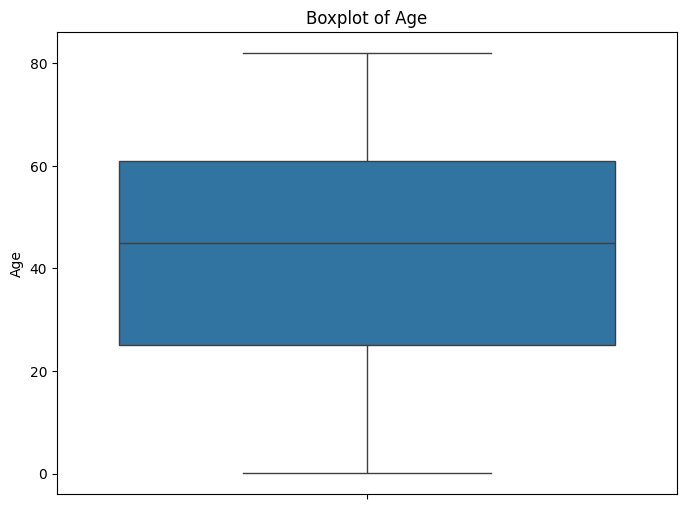

In [95]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()


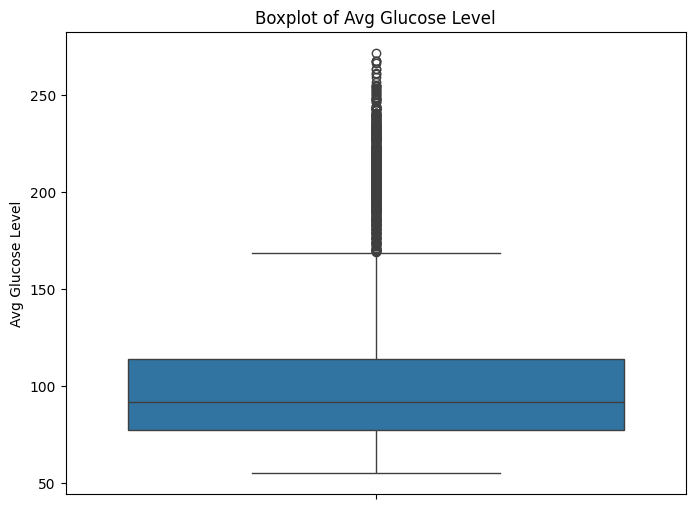

In [96]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['avg_glucose_level'])
plt.title('Boxplot of Avg Glucose Level')
plt.ylabel('Avg Glucose Level')
plt.show()


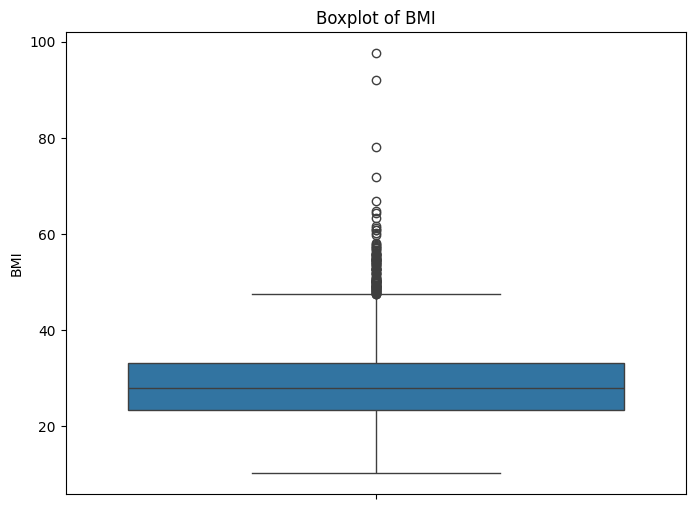

In [97]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['bmi'])
plt.title('Boxplot of BMI')
plt.ylabel('BMI')
plt.show()

# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

Aktivitas:
Melihat perbandingan jumlah kasus stroke berdasarkan kategori tertentu, misalnya gender.

Tujuan:
Mengetahui apakah terdapat perbedaan signifikan jumlah kasus stroke antara laki-laki dan perempuan.

Visualisasi: Bar Chart (Grafik Batang)


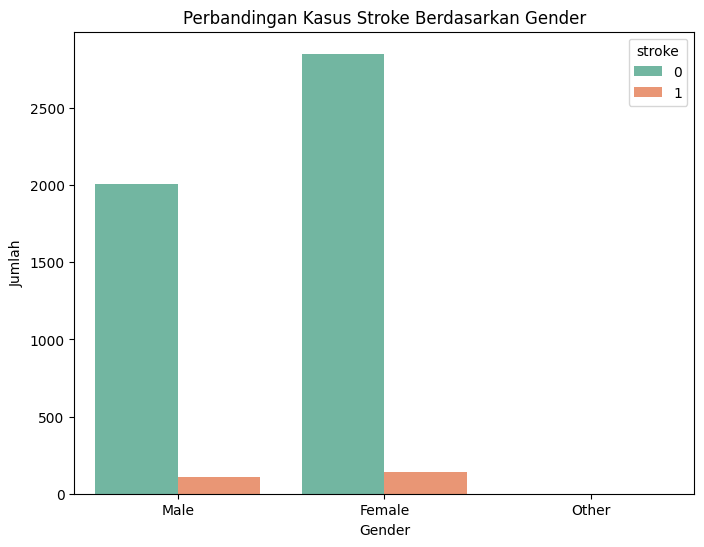

In [98]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gender', hue='stroke', data=df, palette='Set2')
plt.title('Perbandingan Kasus Stroke Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah')
plt.show()

* Dari visualisasi terlihat bahwa jumlah responden perempuan lebih banyak dibandingkan laki-laki.
* Kasus stroke muncul pada kedua gender, tetapi proporsinya relatif mirip.
* Hal ini menunjukkan bahwa gender bukanlah faktor tunggal yang menentukan risiko stroke, sehingga perlu dianalisis bersama variabel lain seperti usia, hipertensi, dan kadar glukosa.


## **Composition/Komposisi**

Aktivitas:
Melihat proporsi atau persentase kategori pada kolom tertentu, misalnya smoking_status.

Tujuan:
Mengidentifikasi status merokok mana yang paling dominan dalam dataset, serta membandingkan kontribusi tiap kategori terhadap keseluruhan populasi.

Visualisasi: Pie Chart (Grafik Lingkaran)


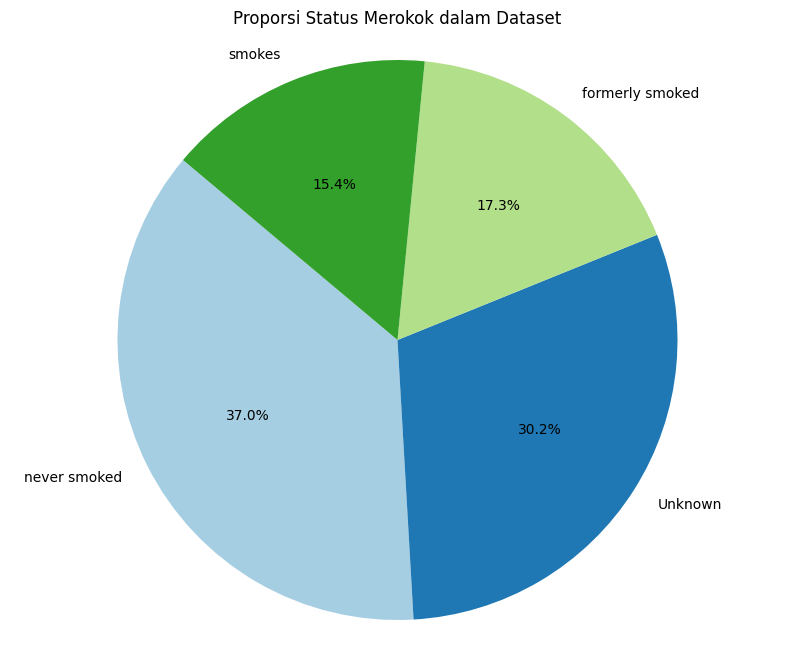

In [99]:
smoking_status_counts = df['smoking_status'].value_counts()

plt.figure(figsize=(10, 8))
smoking_status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi Status Merokok dalam Dataset')
plt.ylabel('')
plt.axis('equal')
plt.show()

* Kategori never smoked mendominasi dengan proporsi terbesar.
* Kategori formerly smoked dan smokes memiliki proporsi lebih kecil.
* Kategori Unknown muncul sebagai data tidak jelas, yang bisa dianggap sebagai missing value terselubung.
* Informasi ini penting karena status merokok merupakan salah satu faktor risiko stroke, sehingga distribusi kategori dapat memengaruhi hasil analisis.


## **Distribution/Distribusi**

Aktivitas:
Menganalisis penyebaran nilai pada kolom numerik, misalnya age.

Tujuan:
Melihat apakah mayoritas responden berada pada kelompok usia tertentu, serta mendeteksi adanya kecondongan (skewness) dalam distribusi data.

Visualisasi: Histogram


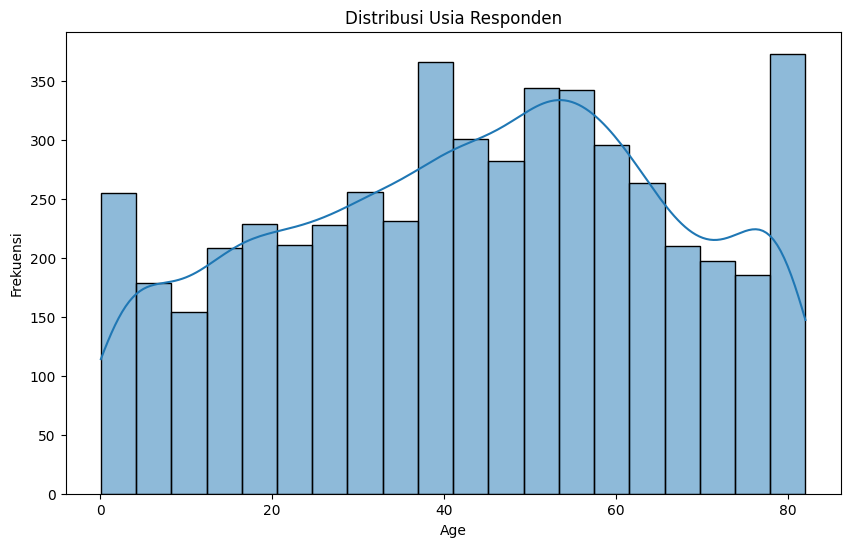

In [100]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribusi Usia Responden')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()

* Distribusi usia menunjukkan mayoritas responden berada pada rentang usia 30–60 tahun.
* Distribusi relatif normal, tetapi terdapat ekor panjang pada usia lanjut (>80 tahun).
* Hal ini penting karena usia merupakan salah satu faktor risiko utama stroke, sehingga distribusi usia dapat memengaruhi hasil analisis.


## **Relationship/Hubungan**

Aktivitas:
Menganalisis korelasi antar variabel numerik, misalnya age, avg_glucose_level, dan bmi.

Tujuan:
Mengetahui apakah terdapat hubungan yang signifikan antar variabel numerik, serta melihat apakah faktor-faktor tersebut saling berkaitan dalam memengaruhi risiko stroke.

Visualisasi: Heatmap


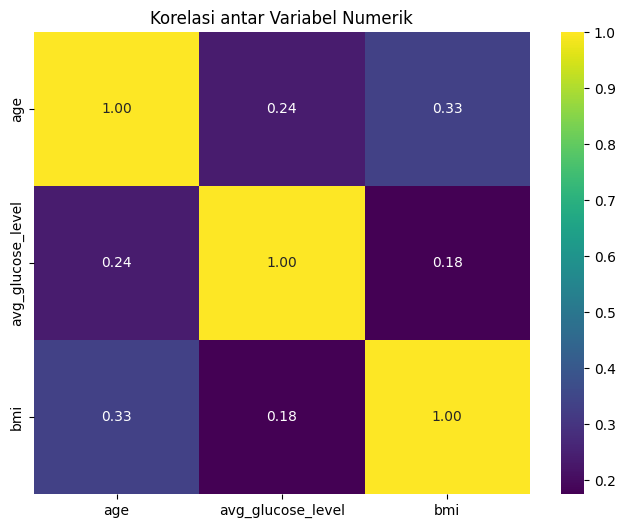

In [101]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['age', 'avg_glucose_level', 'bmi']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antar Variabel Numerik')
plt.show()

* Korelasi antar variabel numerik relatif rendah, menunjukkan bahwa age, avg_glucose_level, dan bmi tidak saling berkaitan secara kuat.
* age memiliki korelasi lemah dengan bmi, yang wajar karena indeks massa tubuh bisa meningkat seiring bertambahnya usia, tetapi tidak selalu konsisten.
* avg_glucose_level tidak berkorelasi signifikan dengan age maupun bmi, menandakan kadar glukosa lebih dipengaruhi oleh faktor medis/riwayat penyakit daripada usia atau berat badan.
* Meskipun korelasi antar variabel rendah, masing-masing variabel tetap penting sebagai faktor risiko stroke dan harus dianalisis secara individual.


# **Data Preparation**

## **Data Type**

## **Incosistent Values**

Pada tahap ini, kita akan menangani ketidakkonsistenan penulisan data yang mungkin terjadi saat proses input data pasien. Hal ini penting agar kategori yang sama tidak dibaca sebagai data yang berbeda oleh sistem hanya karena perbedaan huruf besar atau kecil.

* Menangani Ketidakkonsistenan Penulisan "smoking_status"




Di dalam dataset kesehatan, kolom status merokok (smoking_status) sering kali memiliki format penulisan teks yang tidak seragam (misalnya ada yang huruf kecil semua, atau campuran). Di sini kita menggunakan .str.title() untuk menyeragamkan formatnya, sehingga setiap awalan kata diawali dengan huruf kapital agar datanya lebih rapi dan konsisten saat divisualisasikan nanti.

In [102]:
df['smoking_status'] = df['smoking_status'].str.title()
print(df['smoking_status'].unique())

['Formerly Smoked' 'Never Smoked' 'Smokes' 'Unknown']


## **Missing Values**

Pada tahap ini, kita akan mengecek dan menangani data yang kosong atau hilang (missing values). Prinsip dasarnya mirip: jika persentase data yang hilang sangat besar (misal >= 70%), biasanya kolom tersebut akan dihapus. Namun, jika masih di bawah itu, kita bisa melakukan imputasi (mengisi nilai yang kosong).

Tentu saja, karena ini adalah data kesehatan, kita tidak bisa sembarangan menghapus baris data pasien, karena setiap catatan medis sangat berharga untuk analisis risiko stroke.

In [103]:
print((df.isna().sum() / len(df)) * 100)

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64


**1. Menangani Missing Values pada Kolom "bmi"**

Dari hasil pengecekan, kemungkinan besar kita menemukan adanya data yang kosong pada kolom bmi (Body Mass Index). Karena persentase data yang hilang tidak terlalu ekstrem dan kolom BMI memiliki kaitan medis yang logis terhadap risiko stroke, keputusan yang kita ambil adalah melakukan imputasi, bukan menghapusnya.

Kita akan mengisi nilai BMI yang kosong menggunakan nilai rata-rata (mean) dari keseluruhan data BMI pasien yang tersedia. Hal ini dilakukan untuk menjaga jumlah sampel data tetap utuh tanpa merusak distribusi keseluruhan secara signifikan.

In [104]:
df['bmi'] = df['bmi'].fillna(df['bmi'].dropna().mean())

**2. Mengecek Kembali Missing Values**

Setelah proses imputasi selesai, kita perlu memverifikasi ulang untuk memastikan dataset sudah benar-benar bersih dari nilai kosong (null). Terlihat dari tabel di bawah, persentase data yang hilang di setiap kolom sekarang sudah 0%.

In [105]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio %'])

,Null Ratio %
id,0.0
gender,0.0
age,0.0
hypertension,0.0
heart_disease,0.0
ever_married,0.0
work_type,0.0
Residence_type,0.0
avg_glucose_level,0.0
bmi,0.0


## **Duplicated Values**

In [106]:
df[df.duplicated()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


Pada tahap ini, kita akan mengecek apakah ada duplikasi data pasien di dalam dataset.

Dalam pencatatan rekam medis, duplikasi bisa saja terjadi akibat kesalahan input oleh sistem atau petugas. Jika dibiarkan, data yang berulang ini bisa membuat model analisis kita menjadi bias, seolah-olah ada lebih banyak kasus dengan karakteristik tertentu padahal itu hanya data yang dobel.

Jika output-nya kosong, berarti dataset kita sudah aman. Namun, jika nantinya ditemukan duplikasi, kita bisa menanganinya dengan mudah menggunakan perintah df = df.drop_duplicates().

## **Outliers Values**

Outliers (nilai ekstrem) adalah data yang nilainya terpaut sangat jauh dari mayoritas data lainnya dalam dataset. Dalam konteks data kesehatan seperti rekam medis stroke, outliers bisa saja terjadi bukan karena kesalahan input, melainkan karena kondisi medis pasien yang sebenarnya (misalnya pasien dengan obesitas ekstrem atau kadar gula darah yang sangat tinggi).

Walaupun datanya mungkin valid, nilai yang terlalu ekstrem tetap perlu dikelola karena bisa mengganggu perhitungan statistik dan membuat model analisis kita menjadi bias.

**1. Mendeteksi Persentase Outliers**

Langkah pertama adalah mengecek seberapa besar persentase outliers di setiap kolom numerik. Kita menggunakan metode IQR (Interquartile Range). Metode ini bekerja secara objektif dengan mencari rentang batas bawah (lower bound) dan batas atas (upper bound) berdasarkan pusat sebaran data (50% data di tengah). Data yang berada di luar pagar batas inilah yang dianggap sebagai outliers.

In [107]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
id,0.000000
age,0.000000
hypertension,9.745597
heart_disease,5.401174
avg_glucose_level,12.270059
bmi,2.465753
stroke,4.872798


**2. Menangani Outliers pada "avg_glucose_level"**

Dari pengecekan di atas, kita melihat adanya nilai ekstrem pada kolom avg_glucose_level (rata-rata kadar gula darah). Menghapus baris data pasien dengan gula darah tinggi bukanlah pilihan yang baik, karena justru informasi ini sangat krusial untuk menganalisis risiko stroke.

Oleh karena itu, keputusan yang diambil adalah melakukan teknik clipping. Artinya, kita mempertahankan data pasien tersebut, namun nilai kadar gula darahnya yang terlalu ekstrem dipotong dan dibatasi maksimal hingga nilai batas atas (upper bound) dari perhitungan IQR. Dengan begini, datanya tetap masuk kategori "sangat tinggi" namun tidak merusak distribusi analisis.

In [108]:
Q1 = df['avg_glucose_level'].quantile(0.25)
Q3 = df['avg_glucose_level'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['avg_glucose_level'] = df['avg_glucose_level'].clip(lower=lower_bound, upper=upper_bound)


**3. Mengecek Kembali Nilai Ekstrem**

Setelah proses clipping dilakukan, kita menjalankan ulang pengecekan outliers. Langkah ini bertujuan untuk memverifikasi bahwa nilai ekstrem pada kolom avg_glucose_level sudah berhasil tertangani dengan baik (persentasenya harus turun menjadi 0%).

In [109]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
id,0.000000
age,0.000000
hypertension,9.745597
heart_disease,5.401174
avg_glucose_level,0.000000
bmi,2.465753
stroke,4.872798


# **Construct Data**

Tahap Construct Data adalah proses kreatif dalam analisis data. Di sini, kita tidak lagi hanya membersihkan data, melainkan membuat sesuatu yang baru (fitur baru) dari data yang sudah ada untuk memperkaya hasil analisis nantinya.

**1. Membuat Kolom Baru "health_risk_score"**

Pada dataset stroke ini, riwayat darah tinggi (hypertension) dan penyakit jantung (heart_disease) adalah dua faktor risiko utama. Kedua kolom ini memiliki nilai biner, yaitu 0 (tidak memiliki riwayat penyakit) dan 1 (memiliki riwayat penyakit).

Untuk mempermudah analisis dan memetakan seberapa rentan kondisi seorang pasien, kita bisa mengonstruksi kolom baru bernama health_risk_score (skor risiko kesehatan). Caranya sangat sederhana, yaitu dengan menjumlahkan nilai dari kedua kolom tersebut:

* Skor 0: Pasien tidak memiliki riwayat darah tinggi maupun penyakit jantung (risiko rendah).

* Skor 1: Pasien memiliki salah satu dari riwayat penyakit tersebut (risiko menengah).

* Skor 2: Pasien memiliki kedua riwayat penyakit tersebut (risiko tinggi).

In [110]:
df['health_risk_score'] = df['hypertension'] + df['heart_disease']

**2. Mengecek Kolom Baru Apakah Sudah Tersedia**

Langkah selanjutnya adalah menampilkan beberapa baris teratas dari ketiga kolom tersebut untuk memastikan bahwa kolom health_risk_score sudah berhasil terbuat dan logika penjumlahannya sudah tepat.

In [111]:
df[['hypertension', 'heart_disease', 'health_risk_score']].head()

,hypertension,heart_disease,health_risk_score
0,0,1,1
1,0,0,0
2,0,1,1
3,0,0,0
4,1,0,1


# **Data Reduction**

Tahap Data Reduction (Pengurangan Data) bertujuan untuk menyederhanakan dataset tanpa menghilangkan informasi penting. Fokusnya adalah membuang data yang "berisik" (noisy), tidak relevan, atau terlalu detail sehingga proses analisis menjadi lebih cepat dan hasil visualisasinya lebih bersih.

Pada dataset kesehatan ini, kita akan menghapus kolom id. Nomor identitas pasien hanyalah deretan angka acak untuk keperluan administrasi dan sama sekali tidak memiliki hubungan sebab-akibat dengan risiko stroke. Membiarkan kolom ini justru bisa menjadi noise yang mengganggu jika nantinya data ini dimasukkan ke dalam model machine learning.



**1. Menghapus Kolom "id"**

In [112]:
df = df.drop('id', axis=1)

# **Bar Chart**

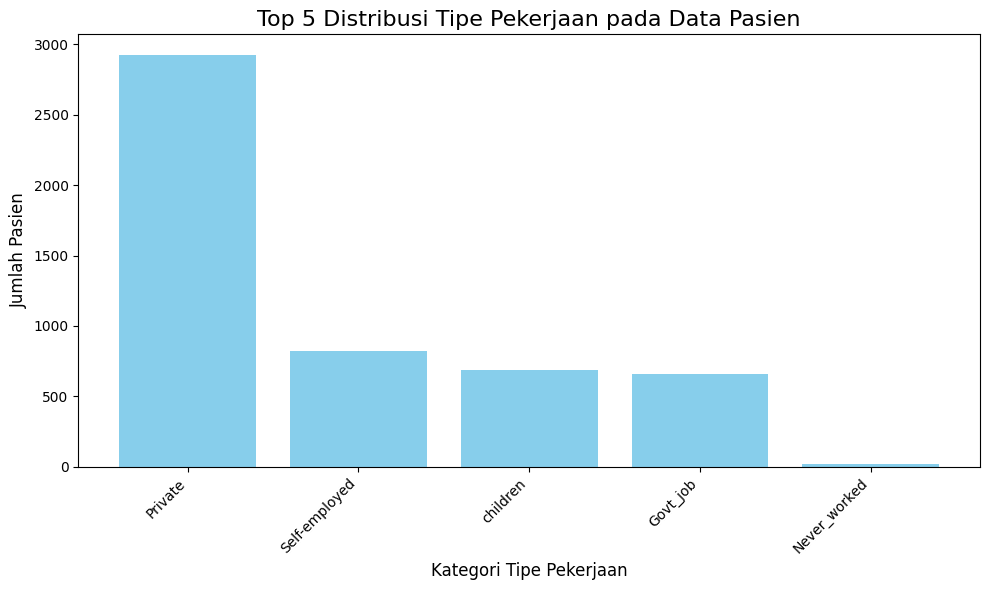

In [113]:
# Menghitung 5 tipe pekerjaan teratas berdasarkan frekuensi (jumlah pasien)
tipe_pekerjaan = df['work_type'].value_counts().head(5).sort_values(ascending=False)

# Membuat Bar Chart
plt.figure(figsize=(10, 6)) # Ukuran figure
plt.bar(tipe_pekerjaan.index, tipe_pekerjaan.values, color='skyblue') # Menggunakan data tipe_pekerjaan
plt.xlabel('Kategori Tipe Pekerjaan', fontsize=12) # Keterangan X label
plt.ylabel('Jumlah Pasien', fontsize=12) # Keterangan Y label
plt.title('Top 5 Distribusi Tipe Pekerjaan pada Data Pasien', fontsize=16) # Judul grafik
plt.xticks(rotation=45, ha='right') # Rotasi teks agar rapi
plt.tight_layout()
plt.show()

Berdasarkan diagram batang (bar chart) yang telah dibuat, dapat dilihat bahwa mayoritas pasien dalam dataset ini bekerja di sektor swasta (Private), yaitu sebanyak 2.925 orang. Jumlah ini memiliki selisih yang sangat besar dibandingkan dengan jenis pekerjaan lainnya, seperti pekerja lepas (Self-employed) atau pegawai pemerintahan (Govt_job) yang masing-masing berjumlah di bawah 900 orang. Hal ini menunjukkan bahwa pekerja di sektor swasta memiliki kecenderungan atau risiko masalah kesehatan yang lebih tinggi, yang kemungkinan disebabkan oleh pola kerja sedenter (kurang gerak) selama di kantor atau tingkat stres pekerjaan. Sebagai tindak lanjut, disarankan agar pihak fasilitas kesehatan dapat memprioritaskan program penyuluhan dan pemeriksaan kesehatan rutin (Medical Check-Up) yang ditargetkan langsung ke area perkantoran swasta, sehingga upaya pencegahan dan deteksi dini penyakit dapat dilakukan dengan lebih efektif.

# **Pie Chart**

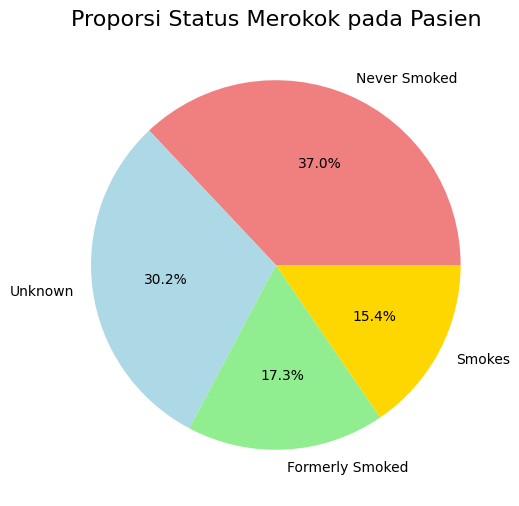

In [114]:
# Membuat Pie Chart untuk kolom 'smoking_status'
plt.figure(figsize=(10, 6)) # Ukuran figure
plt.pie(df['smoking_status'].value_counts(),
        labels=df['smoking_status'].value_counts().index,
        autopct='%1.1f%%',
        colors=['lightcoral', 'lightblue', 'lightgreen', 'gold']) # Kombinasi warna
plt.title('Proporsi Status Merokok pada Pasien', fontsize=16) # Judul grafik
plt.show()

Berdasarkan diagram lingkaran (pie chart) yang menampilkan proporsi status merokok pasien, diketahui bahwa kelompok terbesar merupakan pasien yang tidak pernah merokok (never smoked) dengan persentase mencapai sekitar 37%, disusul oleh kelompok dengan status pencatatan yang tidak diketahui (Unknown) sebesar 30,2%. Meskipun kelompok mayoritas tidak merokok, gabungan persentase pasien yang memiliki riwayat paparan nikotin secara langsung baik mantan perokok (formerly smoked) maupun perokok aktif (smokes) tetap berada pada angka yang signifikan, yakni sekitar 32%. Tingginya persentase kategori Unknown mengindikasikan adanya kelemahan dalam proses screening atau kelengkapan pencatatan rekam medis di fasilitas kesehatan. Sebagai tindak lanjut, pihak administrasi dan tenaga medis disarankan untuk mengevaluasi Standar Operasional Prosedur (SOP) pendataan rekam medis agar riwayat gaya hidup pasien dicatat secara lebih komprehensif. Selain itu, edukasi mengenai bahaya paparan asap rokok pasif (second-hand smoke) juga perlu digalakkan untuk melindungi kelompok pasien never smoked dari risiko penyakit kardiovaskular dan stroke.

# **Line Chart**

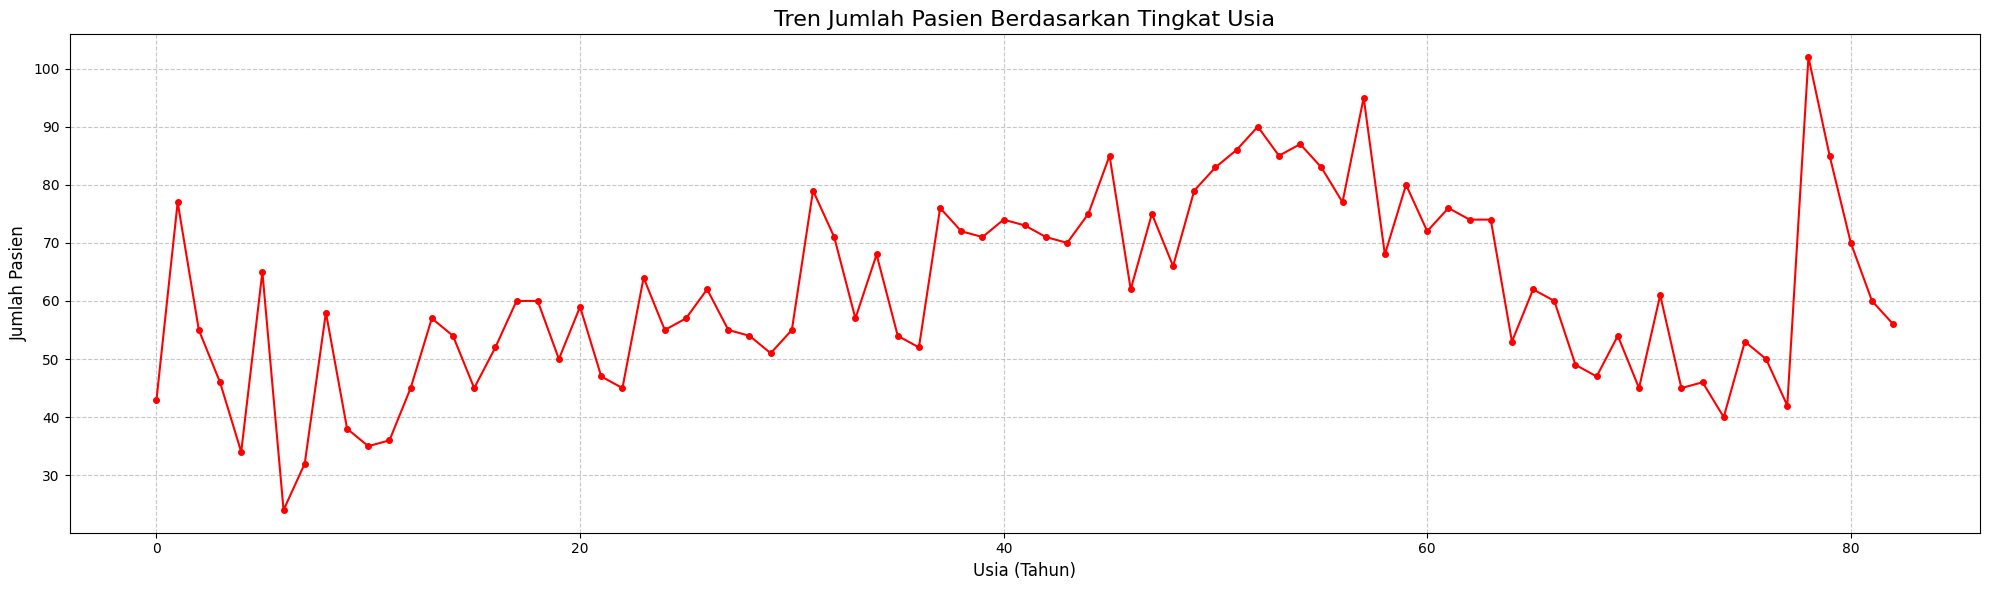

In [115]:
# Membulatkan usia menjadi bilangan bulat agar pengelompokan (grouping) lebih rapi
df['age_rounded'] = df['age'].astype(int)

# Mengelompokkan jumlah pasien berdasarkan usia (menggantikan fungsi dt.year)
jumlah_pasien_per_usia = df.groupby('age_rounded').size()

# Membuat Line Chart
plt.figure(figsize=(20, 6)) # Ukuran figure
plt.plot(jumlah_pasien_per_usia.index, jumlah_pasien_per_usia.values, marker='o', color='red', markersize=4, linewidth=1.5)
plt.title('Tren Jumlah Pasien Berdasarkan Tingkat Usia', fontsize=16) # Judul
plt.xlabel('Usia (Tahun)', fontsize=12) # X Keterangan
plt.ylabel('Jumlah Pasien', fontsize=12) # Y Keterangan
plt.grid(True, linestyle='--', alpha=0.7) # Menambahkan grid agar lebih mudah dibaca
plt.tight_layout()
plt.show()

Analisis visualisasi grafik garis (line chart) terhadap distribusi usia pasien memperlihatkan adanya fluktuasi jumlah individu seiring bertambahnya usia. Puncak jumlah pasien secara signifikan terkonsentrasi pada rentang usia paruh baya hingga pra-lansia (sekitar usia 40 hingga 60 tahun), sebelum akhirnya mengalami tren penurunan yang konsisten pada kelompok usia lanjut di atas 65 tahun. Penurunan pada usia senja ini secara demografis lazim terjadi akibat berkurangnya populasi sejalan dengan angka harapan hidup, sementara tingginya angka kunjungan medis pada usia paruh baya mengindikasikan masa kritis di mana gejala penyakit metabolik dan kardiovaskular mulai bermanifestasi. Sebagai tindak lanjut, manajemen fasilitas kesehatan direkomendasikan untuk memformulasikan paket layanan pemeriksaan preventif (medical check-up) yang secara khusus menargetkan individu pada rentang usia 40 hingga 60 tahun. Selain itu, alokasi tenaga medis seperti spesialis penyakit dalam dan kardiologi perlu disiagakan untuk menangani kelompok usia dengan volume tertinggi ini guna menekan angka keparahan penyakit seperti stroke.

# **Histogram**

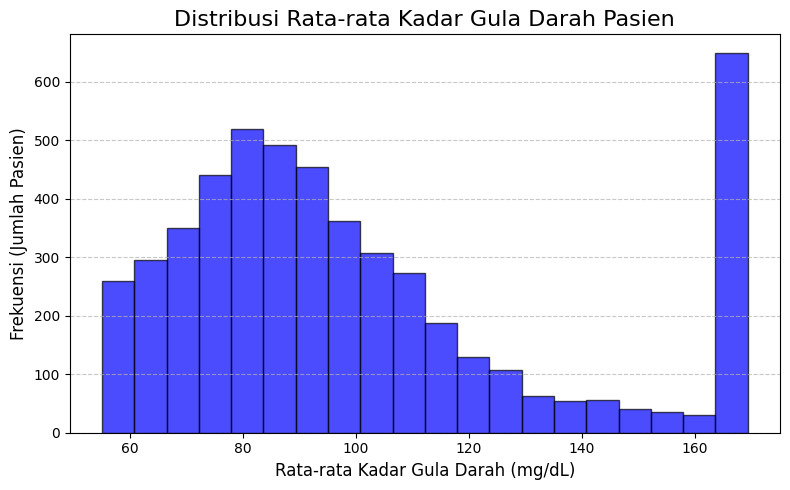

In [116]:
# Membuat Histogram untuk kolom avg_glucose_level
plt.figure(figsize=(8, 5)) # Ukuran figure
plt.hist(df['avg_glucose_level'], bins=20, color='blue', edgecolor='black', alpha=0.7) # Alpha untuk sedikit transparansi
plt.title('Distribusi Rata-rata Kadar Gula Darah Pasien', fontsize=16) # Judul
plt.xlabel('Rata-rata Kadar Gula Darah (mg/dL)', fontsize=12) # X Keterangan
plt.ylabel('Frekuensi (Jumlah Pasien)', fontsize=12) # Y Keterangan
plt.grid(axis='y', linestyle='--', alpha=0.7) # Menambahkan grid horizontal
plt.tight_layout()
plt.show()

Berdasarkan visualisasi histogram terhadap distribusi rata-rata kadar gula darah (average glucose level) pasien, terlihat bahwa persebaran data bersifat condong ke kanan (right-skewed). Mayoritas observasi terkonsentrasi pada rentang nilai 50 hingga 125 mg/dL, yang secara medis masih tergolong dalam batas normal hingga pra-diabetes. Namun, temuan yang patut diwaspadai adalah keberadaan ekor panjang (long tail) pada sisi kanan grafik, yang mengindikasikan adanya kelompok pasien minoritas namun signifikan dengan kadar gula darah sangat tinggi (berkisar antara 150 hingga hampir 300 mg/dL). Kondisi hiperglikemia pada kelompok ini merupakan salah satu faktor risiko utama komplikasi stroke. Oleh karena itu, sebagai tindak lanjut, pihak tenaga medis disarankan untuk menerapkan protokol pemantauan glukosa yang lebih ketat serta memberikan intervensi diet dan pengobatan spesifik bagi sub-populasi pasien yang berada pada rentang nilai ekstrem tersebut, guna mengendalikan faktor pemicu penyerta sebelum berkembang menjadi serangan stroke.

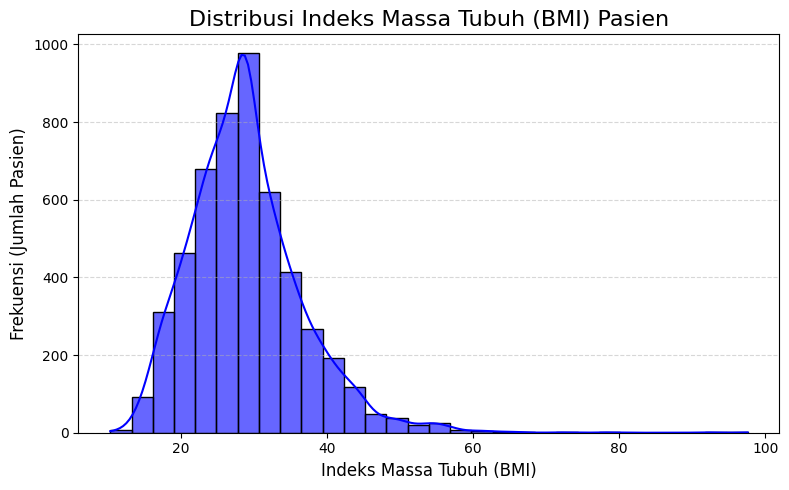

In [117]:
# Membuat Histogram dengan KDE menggunakan Seaborn
plt.figure(figsize=(8, 5)) # Ukuran figure
sns.histplot(df['bmi'], bins=30, kde=True, color='blue', alpha=0.6) # Menggunakan 30 bins agar persebaran lebih detail
plt.title('Distribusi Indeks Massa Tubuh (BMI) Pasien', fontsize=16) # Judul
plt.xlabel('Indeks Massa Tubuh (BMI)', fontsize=12) # X Keterangan
plt.ylabel('Frekuensi (Jumlah Pasien)', fontsize=12) # Y Keterangan
plt.grid(axis='y', linestyle='--', alpha=0.5) # Menambahkan grid horizontal
plt.tight_layout()
plt.show()

Analisis terhadap visualisasi histogram yang dilengkapi dengan kurva estimasi kepadatan kernel (Kernel Density Estimate / KDE) memperlihatkan bahwa distribusi Indeks Massa Tubuh (BMI) pasien memiliki kemiringan positif atau condong ke kanan (right-skewed). Puncak kepadatan data (modus) yang direpresentasikan oleh puncak kurva KDE tidak berada pada rentang berat badan ideal (18,5–24,9), melainkan bergeser ke area overweight atau kelebihan berat badan pada kisaran angka 25 hingga 32. Selain itu, ekor kurva yang menjulur panjang ke sisi kanan mengonfirmasi keberadaan sub-populasi pasien dengan tingkat obesitas morbid (BMI di atas 40). Mengingat pergeseran tren populasi yang cenderung mengarah pada kelebihan berat badan ini, pihak institusi kesehatan direkomendasikan untuk mengintegrasikan konseling dietetik dan manajemen berat badan ke dalam layanan primer rawat jalan. Intervensi proaktif pada manajemen kalori dan aktivitas fisik ini sangat krusial untuk meminimalisasi beban metabolik pasien, yang secara literatur medis merupakan salah satu katalis utama terjadinya komplikasi penyakit jantung dan stroke.

# **BoxPlot**

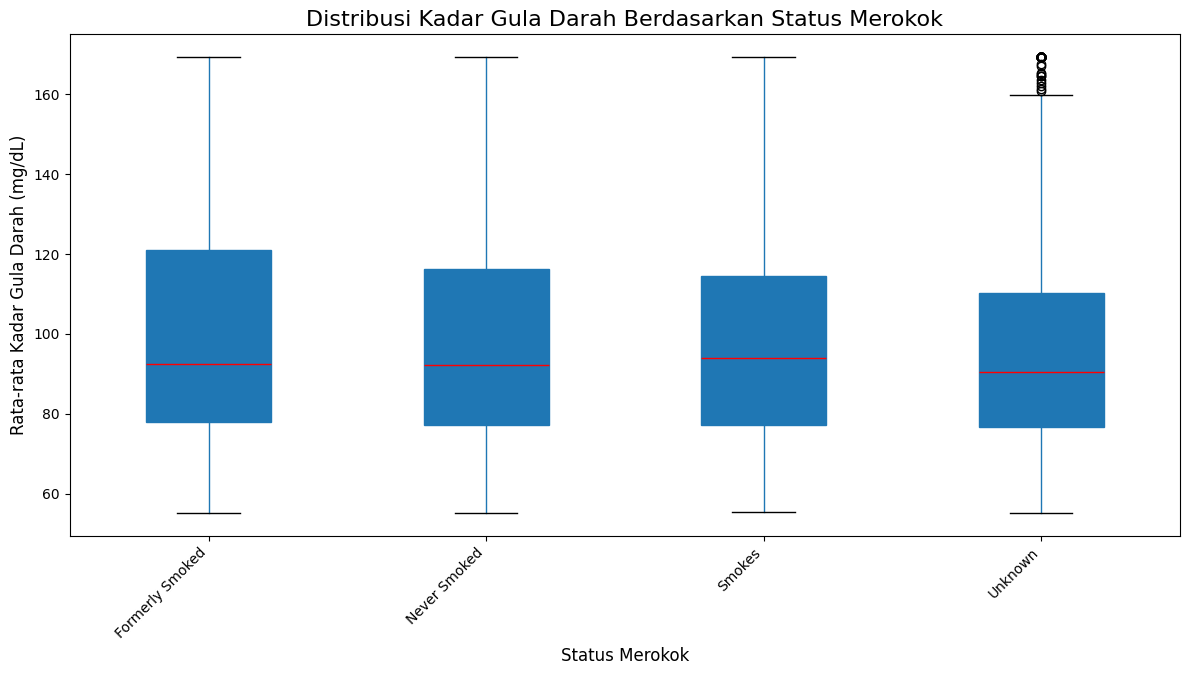

In [118]:
# Mengidentifikasi kategori status merokok teratas (karena hanya ada 4 kategori, semuanya otomatis masuk)
kategori_rokok = df['smoking_status'].value_counts().head(5).index

# Memfilter DataFrame (walaupun dalam kasus ini memuat semua data status merokok)
df_filtered = df[df['smoking_status'].isin(kategori_rokok)]

# Membuat BoxPlot
plt.figure(figsize=(12, 7)) # Ukuran figure
df_filtered.boxplot(column='avg_glucose_level', by='smoking_status', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))
plt.title('Distribusi Kadar Gula Darah Berdasarkan Status Merokok', fontsize=16) # Judul
plt.xlabel('Status Merokok', fontsize=12) # X Keterangan
plt.ylabel('Rata-rata Kadar Gula Darah (mg/dL)', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right') # Rotasi label X agar tidak tumpang tindih
plt.suptitle('') # Menghilangkan judul default dari fungsi boxplot.by
plt.tight_layout()
plt.show()

Berdasarkan visualisasi boxplot yang membandingkan rata-rata kadar gula darah lintas kategori status merokok, ditemukan bahwa nilai tengah (median) dari keempat kelompok tersebut berada pada level yang relatif seragam (berkisar di angka 90-100 mg/dL). Namun, temuan yang paling menonjol adalah banyaknya titik-titik pencilan (outliers) yang menjuntai jauh di atas batas atas kumis (upper whisker) pada semua kategori, terutama pada kelompok never smoked dan formerly smoked. Keberadaan outliers ini mengindikasikan bahwa kondisi hiperglikemia ekstrem dapat dialami oleh pasien terlepas dari apakah mereka memiliki riwayat merokok atau tidak. Sebagai tindak lanjut, tenaga medis disarankan untuk tidak menjadikan status merokok sebagai satu-satunya tolok ukur utama dalam memprediksi risiko diabetes bawaan atau komplikasi stroke. Fasilitas kesehatan perlu menerapkan protokol penapisan (screening) glukosa darah secara universal dan mewajibkan tes HbA1c bagi seluruh pasien dewasa, terlepas dari rekam jejak gaya hidup terkait konsumsi tembakau mereka.

# **ScatterPlot**

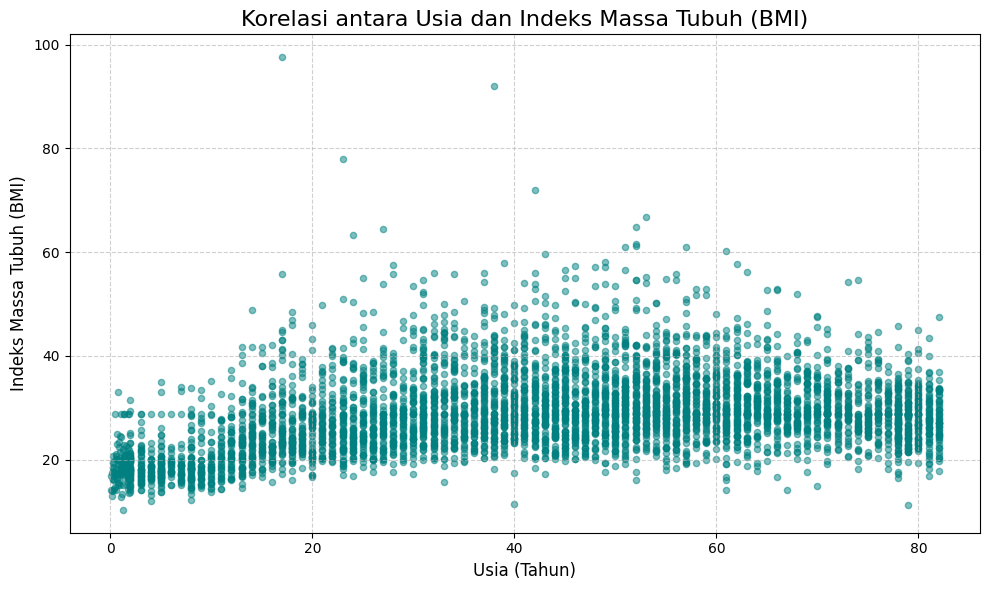

In [119]:
# Membuat ScatterPlot untuk Usia vs BMI
plt.figure(figsize=(10, 6)) # Ukuran figure
plt.scatter(df['age'], df['bmi'], alpha=0.5, color='teal', s=20) # Menggunakan alpha 0.5 agar titik yang menumpuk terlihat jelas
plt.title('Korelasi antara Usia dan Indeks Massa Tubuh (BMI)', fontsize=16) # Judul
plt.xlabel('Usia (Tahun)', fontsize=12) # X Keterangan
plt.ylabel('Indeks Massa Tubuh (BMI)', fontsize=12) # Y Keterangan
plt.grid(True, linestyle='--', alpha=0.6) # Menambahkan grid
plt.tight_layout()
plt.show()

Berdasarkan visualisasi scatterplot yang memetakan hubungan antara usia dan Indeks Massa Tubuh (BMI), terlihat adanya pola kurva pertumbuhan yang khas; pada rentang usia anak-anak hingga remaja (0–20 tahun), nilai BMI menunjukkan tren peningkatan yang linier sejalan dengan masa pertumbuhan fisik. Namun, memasuki usia dewasa (20–60 tahun), sebaran titik data menjadi sangat bervariasi dan menyebar luas, di mana sebagian besar pasien terpusat pada rentang BMI 25 hingga 40, yang secara medis terklasifikasi sebagai overweight (kelebihan berat badan) hingga obesitas tingkat lanjut. Selain itu, terdapat pula beberapa titik pencilan (outliers) ekstrem dengan BMI di atas 60. Memasuki usia lanjut (di atas 60 tahun), sebaran BMI tampak sedikit menurun dan kembali menyempit. Sebagai tindak lanjut, fasilitas kesehatan perlu merancang program intervensi gizi dan edukasi gaya hidup aktif yang ditargetkan secara spesifik pada pasien usia produktif (20-60 tahun) guna mengendalikan lonjakan angka obesitas. Penanganan khusus berupa program manajemen berat badan intensif juga wajib diberikan kepada pasien dengan BMI ekstrem, mengingat obesitas merupakan penyumbang risiko mayor terhadap serangan stroke dan penyakit jantung koroner.

# **Heatmap**

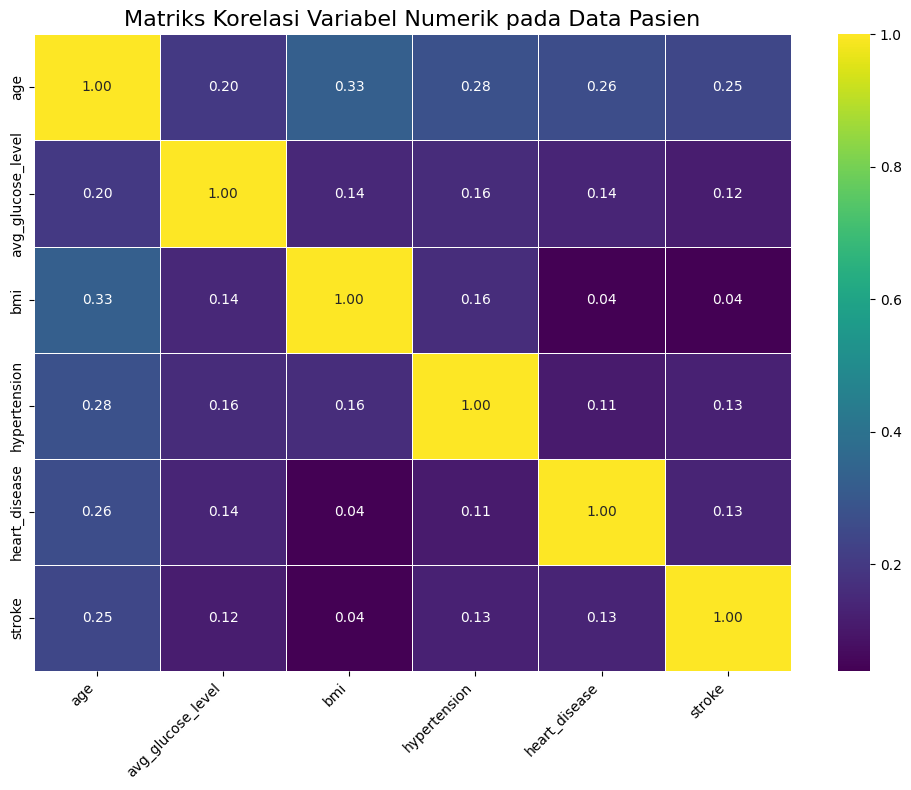

In [120]:
# Mendefinisikan kolom-kolom numerik yang ingin dilihat korelasinya
kolom_numerik = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']

# Membuat Heatmap Korelasi
plt.figure(figsize=(10, 8)) # Ukuran figure disesuaikan agar matriks terlihat proporsional
sns.heatmap(data=df[kolom_numerik].corr(),
            annot=True, # Menampilkan angka korelasi di dalam kotak
            cmap='viridis', # Menggunakan palet warna viridis
            fmt='.2f', # Membulatkan dua angka di belakang koma
            linewidths=0.5) # Menambahkan garis batas antar kotak agar rapi
plt.title('Matriks Korelasi Variabel Numerik pada Data Pasien', fontsize=16) # Judul
plt.xticks(rotation=45, ha='right') # Memutar label sumbu X
plt.tight_layout()
plt.show()

Berdasarkan pemodelan matriks korelasi (heatmap) terhadap variabel numerik pasien, teridentifikasi bahwa tidak ada korelasi linier yang sangat kuat (mendekati angka 1 atau -1) antarvariabel dalam dataset ini. Namun, variabel usia (age) menempati posisi sentral dengan tingkat korelasi positif paling menonjol terhadap hampir seluruh metrik risiko kesehatan lainnya, seperti hipertensi (0.28), riwayat penyakit jantung (0.26), dan indikasi kejadian stroke (0.25). Temuan yang cukup anomali adalah variabel Indeks Massa Tubuh (bmi) ternyata memiliki korelasi langsung yang sangat lemah (mendekati 0.04) terhadap kejadian stroke, yang membuktikan bahwa berat badan berlebih tidak secara tunggal memicu stroke tanpa adanya komplikasi penyerta lain seiring bertambahnya usia. Sebagai tindak lanjut strategis, institusi pelayanan kesehatan direkomendasikan untuk beralih dari metode diagnosis tunggal menuju pendekatan penilaian risiko kardiovaskular secara holistik. Standar Operasional Prosedur (SOP) screening ganda seperti pemeriksaan detak jantung dan tekanan darah secara bersamaan harus diwajibkan bagi setiap pasien yang telah melewati ambang batas usia paruh baya, terlepas dari apakah profil fisik dan indeks massa tubuh (BMI) mereka terlihat normal di permukaan.

# **Menyimpan Dataset (Bersih)**

In [121]:
df.to_excel("[Bersih]healthcare dataset stroke data.xlsx", index=False)